# Thousands of whole-body-control QPs in parallel — a batched robot-arm example

A **whole-body controller (WBC)** turns a desired motion into joint commands by solving a small
**quadratic program (QP)** at every control tick. This notebook builds a batch of *independent*
fixed-base robot-arm WBC QPs (KUKA iiwa14), each at a different random state, and solves the
**whole batch in a single GPU call** -- the batch dimension is the leading axis of every array, so
thousands of QPs ride the GPU's parallelism together. We then check the solutions are feasible and
measure how throughput scales with the batch size.

To run this notebook, you will need to install [Pinocchio](https://github.com/stack-of-tasks/pinocchio) and [robot_descriptions](https://github.com/robot-descriptions/robot_descriptions.py).

In [1]:
%pip install pin robot_descriptions

# restart kernel to use updated packages
%reset -f

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import pinocchio as pin
from robot_descriptions.loaders.pinocchio import load_robot_description

from cupiqp import DenseSolver, Status

print("cupy device:", cp.cuda.Device().id, "-",
      cp.cuda.runtime.getDeviceProperties(0)["name"].decode())

cupy device: 0 - NVIDIA GeForce RTX 5090


## The robot-arm WBC QP

For a fixed-base arm with $n_a$ actuated joints, one WBC tick solves

$$
\min_{x}\;\; \tfrac12\, x^\top P\, x + c^\top x
\quad\text{s.t.}\quad
A x = b,\qquad x_\ell \le x \le x_u ,
$$

with the decision variable $x$ stacking the joint **accelerations** $\dot u$ and **torques** $\tau$:

$$
x = \begin{bmatrix}\dot u\\[2pt]\tau\end{bmatrix}\in\mathbb{R}^{2 n_a}.
$$

**Equality -- the equation of motion** (fixed base, fully actuated):

$$
M(q)\,\dot u \;-\; \tau \;=\; -\,\mathrm{nle}(q,v),
$$

where $M(q)$ is the joint-space inertia matrix and $\mathrm{nle}(q,v)=C(q,v)\,v+g(q)$ is the
Coriolis-plus-gravity term, evaluated at the joint position $q$ and velocity $v$.

**Box -- torque limits** (cuPIQP takes these as per-variable bounds, *not* extra constraint rows):

$$
-\tau_{\lim}\le \tau \le \tau_{\lim}.
$$

**Cost -- a weighted sum of tasks:**

- end-effector acceleration tracking $\;w_{ee}\,\lVert J_{ee}\,\dot u - b_{ee}\rVert^2$, with
  $b_{ee}=a^{\mathrm{des}}_{ee}-\dot J_{ee} v$ and a PD law
  $a^{\mathrm{des}}_{ee}=K^{ee}_p(p^{\mathrm{des}}-p)+K^{ee}_d(v^{\mathrm{des}}-\dot p)$, where
  $J_{ee}$ is the end-effector Jacobian;
- posture regularization $\;w_{\mathrm{post}}\lVert\dot u-\dot u_{\mathrm{ref}}\rVert^2$;
- torque regularization $\;w_\tau\lVert\tau\rVert^2$;
- a tiny ridge $\varepsilon\lVert x\rVert^2$ to keep $P$ positive definite.

Expanding the least-squares tasks gives the blocks of $P$ and $c$ assembled below.

## Robot model, dynamics, and a batch of QPs

`pinocchio` gives us the real $M$, $J_{ee}$, $\dot J_{ee}v$, and $\mathrm{nle}$ for any state
$(q, v)$. We use it to assemble $B$ independent WBC problems at random states, stacked into arrays
whose **leading axis is the batch** -- the layout cuPIQP's dense batched solver expects.

In [3]:
robot = load_robot_description("iiwa14_description")
model = robot.model
data = model.createData()

na = model.nv                       # actuated joints (== nv for a fixed-base arm)
n_dec = 2 * na                      # decision variables: [u_dot; tau]
EE = model.getFrameId("iiwa_link_ee")
q0 = pin.neutral(model)             # nominal posture

# iiwa14 datasheet absolute torque limits (N*m), per joint.
TAU_LIM = np.array([320., 320., 176., 176., 110., 40., 40.])

print(f"iiwa14: na = nv = {na},  nq = {model.nq},  decision vars n = {n_dec}")


def arm_dynamics(q, v):
    """Return (M, J_ee_lin, dJv_ee_lin, nle, ee_pos, ee_vel_lin) at state (q, v)."""
    pin.forwardKinematics(model, data, q, v)
    pin.computeJointJacobians(model, data, q)
    pin.computeJointJacobiansTimeVariation(model, data, q, v)
    pin.updateFramePlacements(model, data)
    pin.crba(model, data, q)
    M = data.M.copy()
    # CRBA only fills the upper triangle; mirror it.
    M[np.tril_indices_from(M, -1)] = M.T[np.tril_indices_from(M, -1)]
    pin.nonLinearEffects(model, data, q, v)

    J6 = pin.getFrameJacobian(model, data, EE, pin.LOCAL_WORLD_ALIGNED)
    dJ6 = pin.getFrameJacobianTimeVariation(model, data, EE, pin.LOCAL_WORLD_ALIGNED)
    vel = pin.getFrameVelocity(model, data, EE, pin.LOCAL_WORLD_ALIGNED)
    return (M, J6[:3].copy(), dJ6[:3] @ v, data.nle.copy(),
            data.oMf[EE].translation.copy(), vel.linear.copy())

iiwa14: na = nv = 7,  nq = 7,  decision vars n = 14


In [4]:
# Task weights and PD gains (shared across the batch).
W_EE, W_POST, W_TAU, RIDGE = 100.0, 1.0, 1e-3, 1e-6
KP_EE, KD_EE = 100.0, 20.0
KP_POST, KD_POST = 25.0, 10.0


def build_batch(B, seed=0):
    """Assemble B random iiwa14 WBC QPs as batched numpy arrays."""
    rng = np.random.default_rng(seed)
    I = np.eye(na)

    P = np.zeros((B, n_dec, n_dec))
    c = np.zeros((B, n_dec))
    A = np.zeros((B, na, n_dec))
    b = np.zeros((B, na))
    x_l = np.full((B, n_dec), -np.inf)
    x_u = np.full((B, n_dec), +np.inf)

    for k in range(B):
        # Random state near the nominal posture (clipped to stay away from
        # kinematic singularities that would make M / J ill-conditioned).
        q = q0 + np.clip(rng.standard_normal(model.nq), -2, 2) * 0.3
        v = np.clip(rng.standard_normal(na), -2, 2) * 0.5
        M, J, dJv, nle, ee_pos, ee_vel = arm_dynamics(q, v)

        # End-effector PD target -> desired cartesian acceleration -> task RHS.
        p_des = ee_pos + rng.uniform(-0.05, 0.05, 3)
        v_des = rng.uniform(-0.2, 0.2, 3)
        a_ee_des = KP_EE * (p_des - ee_pos) + KD_EE * (v_des - ee_vel)
        b_ee = a_ee_des - dJv
        u_dot_ref = -KP_POST * (q - q0)[:na] - KD_POST * v

        # Cost blocks:  P = [[w_ee J^T J + w_post I, 0], [0, w_tau I]] + ridge.
        P[k, :na, :na] = W_EE * (J.T @ J) + W_POST * I
        P[k, na:, na:] = W_TAU * I
        P[k] += RIDGE * np.eye(n_dec)
        c[k, :na] = -W_EE * (J.T @ b_ee) - W_POST * u_dot_ref

        # Equality: M u_dot - tau = -nle.
        A[k, :, :na] = M
        A[k, :, na:] = -I
        b[k] = -nle

        # Box: torque limits on the tau block; u_dot unbounded.
        x_l[k, na:] = -TAU_LIM
        x_u[k, na:] = +TAU_LIM

    return dict(P=P, c=c, A=A, b=b, x_l=x_l, x_u=x_u)

## Solve the whole batch in one GPU call

Move the batched arrays to the GPU with `cupy`, hand them to `DenseSolver`, and call `solve()`
**once** -- every problem in the batch is solved together.

In [5]:
def solve_batch(qp, tol=1e-8, max_iter=200):
    solver = DenseSolver()
    solver.settings.eps_abs = tol
    solver.settings.max_iter = max_iter
    solver.settings.verbose = False
    solver.setup(
        P=cp.asarray(qp["P"]),   c=cp.asarray(qp["c"]),
        A=cp.asarray(qp["A"]),   b=cp.asarray(qp["b"]),
        x_l=cp.asarray(qp["x_l"]), x_u=cp.asarray(qp["x_u"]),
    )
    solver.solve()
    cp.cuda.Device(0).synchronize()
    return solver


B = 4096
qp = build_batch(B, seed=0)

solver = solve_batch(qp)                 # one call solves all B problems
status = cp.asnumpy(solver.result.info.status)
n_iter = cp.asnumpy(solver.result.info.iter)
n_solved = int((status == Status.CUPIQP_SOLVED).sum())

print(f"Solved {n_solved} / {B} WBC problems in a single batched call.")
print(f"IPM iterations across the batch: min={n_iter.min()}, max={n_iter.max()}")

Solved 4096 / 4096 WBC problems in a single batched call.
IPM iterations across the batch: min=10, max=10


## Check the solutions are feasible

`solver.result.x` is `(B, n)` -- one solution per problem. We verify the equation-of-motion
equality and the torque box on the host.

In [6]:
x = cp.asnumpy(solver.result.x)              # (B, n)

eq_res = np.abs(np.einsum("bij,bj->bi", qp["A"], x) - qp["b"]).max(axis=1)
box_lo = np.maximum(qp["x_l"] - x, 0.0)      # ignores +/-inf bounds via nan-safe max
box_hi = np.maximum(x - qp["x_u"], 0.0)
box_lo[~np.isfinite(qp["x_l"])] = 0.0
box_hi[~np.isfinite(qp["x_u"])] = 0.0
box_viol = np.maximum(box_lo.max(axis=1), box_hi.max(axis=1))

print(f"max |M u_dot - tau + nle|  over the batch : {eq_res.max():.2e}")
print(f"max torque-box violation   over the batch : {box_viol.max():.2e}")

# A peek at one solution.
i = 0
print(f"\nproblem {i}:  |tau|_inf = {np.abs(x[i, na:]).max():6.1f} N*m"
      f"   (limit {TAU_LIM.max():.0f})")

max |M u_dot - tau + nle|  over the batch : 5.79e-12
max torque-box violation   over the batch : 0.00e+00

problem 0:  |tau|_inf =   65.8 N*m   (limit 320)


## Scaling: how throughput grows with the batch

The whole point of batching: a single-thread CPU solver pays *linearly* for every extra problem,
while the GPU solver amortizes launch and orchestration overhead across the batch. cuPIQP also
records the interior-point iteration as a CUDA graph and replays it, so repeated solves are cheap.
We sweep the batch size and measure

$$
\text{throughput}(B) = \frac{B}{t_{\text{solve}}(B)}\quad[\text{QPs / second}].
$$

The largest batch is built once and sliced, so build time is not counted.

In [7]:
BATCH_SIZES = [64, 256, 1024, 4096, 16384]

full = build_batch(max(BATCH_SIZES), seed=0)

solve_ms, throughput = [], []
for B in BATCH_SIZES:
    sub = {k: v[:B] for k, v in full.items()}
    s = solve_batch(sub)                      # warm-up + JIT on first size
    t0 = time.perf_counter()
    s.solve(); cp.cuda.Device(0).synchronize()
    dt = (time.perf_counter() - t0) * 1e3
    solve_ms.append(dt)
    throughput.append(B / (dt / 1e3))
    print(f"B={B:6d}:  solve = {dt:8.2f} ms   ->   {throughput[-1]:10.0f} QPs/s")

B=    64:  solve =     5.28 ms   ->        12124 QPs/s
B=   256:  solve =     5.51 ms   ->        46422 QPs/s
B=  1024:  solve =     7.20 ms   ->       142287 QPs/s
B=  4096:  solve =    14.27 ms   ->       287059 QPs/s
B= 16384:  solve =    43.48 ms   ->       376792 QPs/s


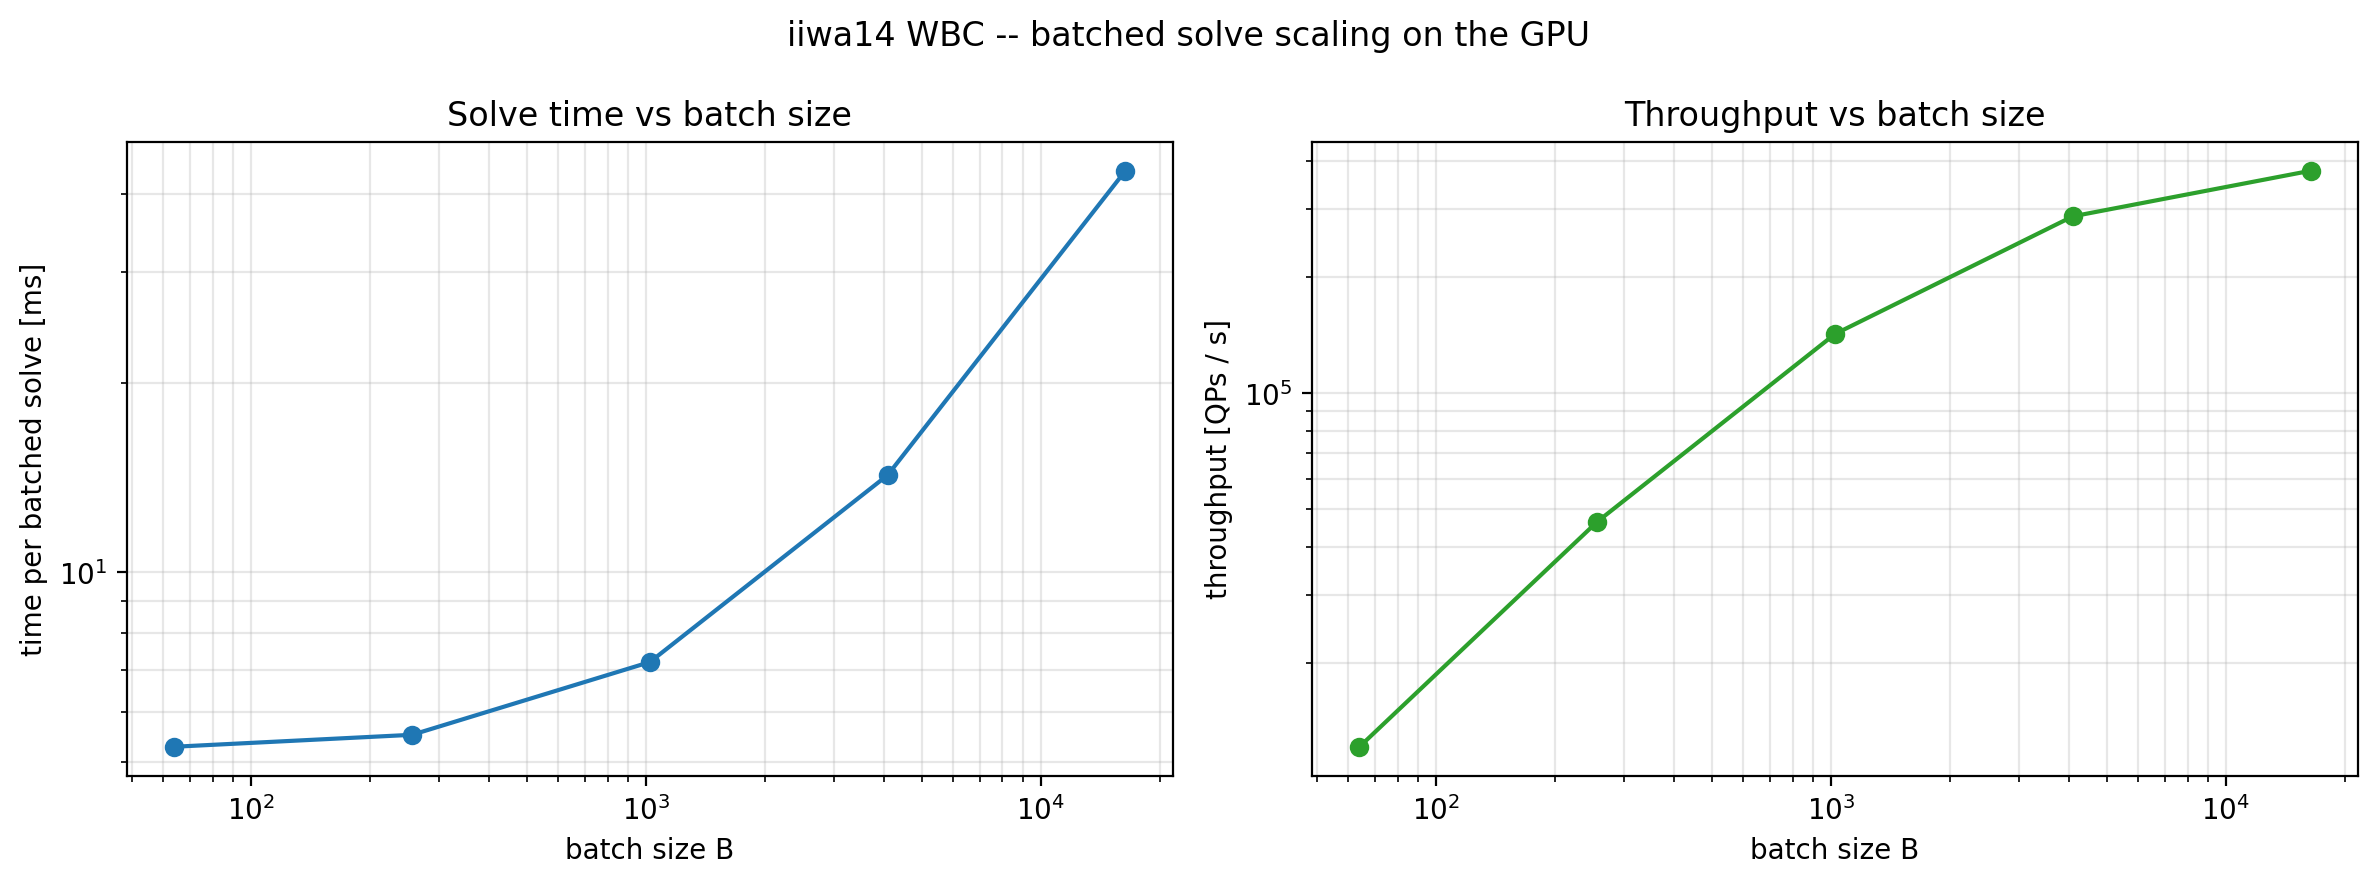

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

axL.loglog(BATCH_SIZES, solve_ms, "o-", color="C0")
axL.set_xlabel("batch size B"); axL.set_ylabel("time per batched solve [ms]")
axL.set_title("Solve time vs batch size"); axL.grid(True, which="both", alpha=0.3)

axR.loglog(BATCH_SIZES, throughput, "o-", color="C2")
axR.set_xlabel("batch size B"); axR.set_ylabel("throughput [QPs / s]")
axR.set_title("Throughput vs batch size"); axR.grid(True, which="both", alpha=0.3)

fig.suptitle("iiwa14 WBC -- batched solve scaling on the GPU")
fig.tight_layout()
plt.show()